# 07 — Retrospective simulation of the 2024/25 league seasons

This notebook estimates how the predicted final tables changed as information arrived during 2024/25. It uses four information snapshots for each competition:

1. **pre-season**;
2. after the completed league block nearest to **25%** of fixtures;
3. after the block nearest to **50%**;
4. after the block nearest to **75%**.

At every snapshot, completed results are fixed and all remaining fixtures are simulated 20,000 times. The Poisson score model is refitted only from seasons 2021/22–2023/24 and the part of 2024/25 already completed at that snapshot.

The notebook answers three applied questions:

- how accurately could the final points and ranks be anticipated at each stage;
- how quickly did title, European-position, and relegation uncertainty disappear;
- where did the structural score model remain uncertain or systematically wrong?

This is a retrospective pseudo-live experiment. No later 2024/25 result is used at an earlier snapshot.

## 1. Data and institutional sources

Match dates, teams, and goals come from [Understat](https://understat.com/), as prepared and checked in Notebook 01. The simulation uses no future market odds, ClubElo values, SoFIFA ratings, xG, or rolling match features. They would require a separate model for their future evolution.

Competition rules and the realised 2024/25 allocation are documented from official sources:

- [UEFA's 2025/26 Champions League access list](https://www.uefa.com/uefachampionsleague/news/0297-1d507af6baee-1bdad04be9b9-1000--2025-26-champions-league-who-is-qualifying-for-the-leagu/);
- the [Premier League final Champions League race](https://www.premierleague.com/en/news/4316771) and its [relegation explanation](https://www.premierleague.com/en/news/58905);
- La Liga's official reports on the [seventh and eighth European positions](https://www.laliga.com/en-US/news/rc-celta-and-rayo-vallecano-seal-their-return-to-european-football) and the [three relegated clubs](https://www.laliga.com/noticias/descensos-primera-division-24-25);
- the Bundesliga's explanation of the [16th-place relegation play-off](https://www.bundesliga.com/en/faq/what-are-the-rules-and-regulations-of-soccer/how-does-promotion-and-relegation-work-in-the-bundesliga-10645);
- Lega Serie A's confirmation that [sixth place entered the Conference League](https://www.legaseriea.it/serie-a/news/fiorentina-obiettivo-europa);
- the official [Ligue 1 standings](https://ligue1.com/competitions/ligue1mcdonalds?tab=ranking).

The event called `European position` means a final league position that obtained Europe under the resolved 2024/25 allocation. Domestic cup winners outside that league-position zone are not simulated. The event therefore remains a property of the league table rather than a model of cup competitions.

In [1]:
from pathlib import Path
import os
import sys
import tempfile
import time
import warnings

logical_cores = max(1, os.cpu_count() or 1)
os.environ["LOKY_MAX_CPU_COUNT"] = str(max(1, min(8, logical_cores - 1)))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "match_prediction_matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DEVELOPMENT_SEASONS, FINAL_TEST_SEASON, PROCESSED_DATA_DIR, RANDOM_STATE
from src.poisson_models import fit_poisson_model
from src.season_simulation import (
    nearest_completed_block,
    position_probability_matrix,
    simulate_remaining_season,
    standings_from_matches,
    summarise_simulations,
    tournament_rank_probability_score,
)
from src.validation import assign_walk_forward_blocks

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 35)
pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 100)

LEAGUES = {
    "BUNDESLIGA": "Bundesliga",
    "EPL": "Premier League",
    "LALIGA": "La Liga",
    "LIGUE_1": "Ligue 1",
    "SERIE_A": "Serie A",
}
COLOURS = {
    "Bundesliga": "#1F77B4",
    "Premier League": "#FF7F0E",
    "La Liga": "#2CA02C",
    "Ligue 1": "#D62728",
    "Serie A": "#9467BD",
}
SNAPSHOTS = [
    ("preseason", "Pre-season", 0.00),
    ("quarter", "Approximately 25%", 0.25),
    ("half", "Approximately 50%", 0.50),
    ("three_quarters", "Approximately 75%", 0.75),
]
N_SIMULATIONS = 20_000

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 10,
    "grid.alpha": 0.22,
})

## 2. League-position events

The simulation reports five events. `Title` means position 1. `Champions League` and `European position` use the resolved 2024/25 allocation. `Direct relegation` excludes a regular play-off position. `Play-off` means entering the promotion/relegation tie, not losing it.

The English and Spanish fifth Champions League positions were European Performance Spots. Using them here does not change any fitted probability; it only labels simulated final ranks after the retrospective season rules are known.

In [2]:
LEAGUE_RULES = {
    "BUNDESLIGA": {
        "champions_league_places": 4,
        "european_places": 6,
        "direct_relegation_places": 2,
        "playoff_position": 16,
        "decay_rate": 0.0,
        "decay_label": "No time decay",
    },
    "EPL": {
        "champions_league_places": 5,
        "european_places": 7,
        "direct_relegation_places": 3,
        "playoff_position": None,
        "decay_rate": np.log(2) / 365.0,
        "decay_label": "365-day half-life",
    },
    "LALIGA": {
        "champions_league_places": 5,
        "european_places": 8,
        "direct_relegation_places": 3,
        "playoff_position": None,
        "decay_rate": np.log(2) / 730.0,
        "decay_label": "730-day half-life",
    },
    "LIGUE_1": {
        "champions_league_places": 4,
        "european_places": 7,
        "direct_relegation_places": 2,
        "playoff_position": 16,
        "decay_rate": np.log(2) / 730.0,
        "decay_label": "730-day half-life",
    },
    "SERIE_A": {
        "champions_league_places": 4,
        "european_places": 6,
        "direct_relegation_places": 3,
        "playoff_position": None,
        "decay_rate": np.log(2) / 730.0,
        "decay_label": "730-day half-life",
    },
}

rule_table = pd.DataFrame([
    {
        "league": LEAGUES[league_id],
        "Champions League positions": rule["champions_league_places"],
        "European league-position zone": f"1–{rule['european_places']}",
        "Direct relegation positions": rule["direct_relegation_places"],
        "Play-off position": rule["playoff_position"] or "None",
        "Locked Poisson weighting": rule["decay_label"],
    }
    for league_id, rule in LEAGUE_RULES.items()
])
display(rule_table.style.hide(axis="index"))

league,Champions League positions,European league-position zone,Direct relegation positions,Play-off position,Locked Poisson weighting
Bundesliga,4,1–6,2,16,No time decay
Premier League,5,1–7,3,None,365-day half-life
La Liga,5,1–8,3,None,730-day half-life
Ligue 1,4,1–7,2,16,730-day half-life
Serie A,4,1–6,3,None,730-day half-life


The thresholds are league-specific. For example, position 16 in Germany and France is separated from direct relegation because it leads to a play-off. England, Spain, and Italy have no regular fixed play-off position in this table summary, so their play-off probability is reported as zero.

## 3. Why the Poisson model is used

For future fixture $i$, the fitted score model generates independent home and away goals:

$$
X_i^{(s)}\sim\operatorname{Poiss}(\widehat\lambda_{H,i}),
\qquad
Y_i^{(s)}\sim\operatorname{Poiss}(\widehat\lambda_{A,i}),
$$

where:

- $s=1,\ldots,S$ identifies one Monte Carlo season;
- $X_i^{(s)}$ and $Y_i^{(s)}$ are the simulated goals in fixture $i$;
- $\widehat\lambda_{H,i}$ and $\widehat\lambda_{A,i}$ are calculated from the snapshot-specific estimates of $\mu$, $\mu_H$, attack, and defence;
- $S=20{,}000$ is the number of simulated seasons.

The points awarded to the home team are

$$
P_{H,i}^{(s)}=
\begin{cases}
3, & X_i^{(s)}>Y_i^{(s)},\\
1, & X_i^{(s)}=Y_i^{(s)},\\
0, & X_i^{(s)}<Y_i^{(s)}.
\end{cases}
$$

Away points are defined symmetrically. Completed matches contribute their realised goals and points to every simulation. Only the remaining fixtures are random.

This model is suitable for long-range prediction because team identity, venue, and the remaining fixture list are known. A structural ML classifier from Notebook 03 cannot be used for the full future schedule without also simulating the future paths of rolling xG, form, rest, and rating features.

## 4. Data scope and prediction horizon

The modelling table is the CSV created by Notebook 02. The next cell confirms the development seasons, the final season, the fixture counts, and the first and last dates before any result is used in a simulation.

In [3]:
features = pd.read_csv(PROCESSED_DATA_DIR / "match_features.csv", parse_dates=["date"])
features = features.sort_values(["date", "league_id", "game_id"]).reset_index(drop=True)

development = features.loc[
    features["season_id"].isin(DEVELOPMENT_SEASONS)
    & features["sample_role"].eq("development")
].copy()
final_test = features.loc[
    features["season_id"].eq(FINAL_TEST_SEASON)
    & features["sample_role"].eq("walk_forward_test")
].copy()

assert development["date"].max() < final_test["date"].min()
assert len(final_test) == 1752
assert final_test[["home_goals", "away_goals"]].notna().all().all()

final_blocked, block_summary = assign_walk_forward_blocks(final_test)
horizon = final_blocked.groupby("league_id").agg(
    fixtures=("game_id", "size"),
    first_match=("date", "min"),
    last_match=("date", "max"),
    teams=("home_team", "nunique"),
).reset_index()
horizon["league"] = horizon["league_id"].map(LEAGUES)
horizon = horizon[["league", "fixtures", "teams", "first_match", "last_match"]]
display(horizon.style.hide(axis="index").format({
    "first_match": lambda value: value.strftime("%d %b %Y"),
    "last_match": lambda value: value.strftime("%d %b %Y"),
}))
display(final_blocked[[
    "date", "league_id", "home_team", "away_team", "home_goals", "away_goals",
    "walk_block", "walk_block_type",
]].sample(10, random_state=42))

league,fixtures,teams,first_match,last_match
Bundesliga,306,18,23 Aug 2024,17 May 2025
Premier League,380,20,16 Aug 2024,25 May 2025
La Liga,380,20,15 Aug 2024,25 May 2025
Ligue 1,306,18,16 Aug 2024,17 May 2025
Serie A,380,20,17 Aug 2024,25 May 2025


,date,league_id,home_team,away_team,home_goals,away_goals,walk_block,walk_block_type
5726,2024-10-05,LIGUE_1,Lille,Toulouse,2,1,7,complete_round
5812,2024-10-26,EPL,Brentford,Ipswich,4,3,9,complete_round
5809,2024-10-26,BUNDESLIGA,St. Pauli,Wolfsburg,0,0,8,complete_round
5866,2024-11-02,EPL,Bournemouth,Manchester City,2,1,10,complete_round
6913,2025-04-20,SERIE_A,Bologna,Inter,1,0,36,complete_round
6646,2025-03-08,EPL,Brighton,Fulham,2,1,30,complete_round
6938,2025-04-26,BUNDESLIGA,Bayern Munich,Mainz 05,3,0,31,complete_round
6203,2024-12-28,SERIE_A,Cagliari,Inter,0,3,18,complete_round
6697,2025-03-15,LALIGA,Girona,Valencia,1,1,33,complete_round
7150,2025-05-25,SERIE_A,Venezia,Juventus,2,3,41,complete_round


All five schedules are complete: 306 fixtures for each 18-team league and 380 for each 20-team league. The representative sample is displayed only to verify the match-level structure. The four snapshots are chosen from complete scheduling blocks rather than by cutting through a matchday.

## 5. Snapshot construction

Let $N_L$ be the total number of fixtures in league $L$ and let $C_b$ be the cumulative number completed after block $b$. For requested fraction $q\in\{0.25,0.50,0.75\}$, the selected block is

$$
b_q=\arg\min_b\left|C_b-qN_L\right|.
$$

This produces the nearest completed league block. Small deviations from exactly 25%, 50%, or 75% are expected because a block contains several concurrent fixtures.

In [4]:
snapshot_rows = []
for league_id, league_name in LEAGUES.items():
    league_fixtures = final_blocked.loc[final_blocked["league_id"].eq(league_id)]
    league_blocks = block_summary.loc[block_summary["league_id"].eq(league_id)]
    total_matches = len(league_fixtures)
    snapshot_rows.append({
        "league_id": league_id,
        "league": league_name,
        "snapshot_order": 0,
        "snapshot_code": "preseason",
        "snapshot": "Pre-season",
        "selected_block": 0,
        "cutoff_date": pd.NaT,
        "completed_matches": 0,
        "remaining_matches": total_matches,
        "completed_fraction": 0.0,
    })
    for order, (snapshot_code, snapshot_label, target_fraction) in enumerate(SNAPSHOTS[1:], start=1):
        selected = nearest_completed_block(league_blocks, target_fraction)
        completed_matches = int(selected["completed_matches"])
        snapshot_rows.append({
            "league_id": league_id,
            "league": league_name,
            "snapshot_order": order,
            "snapshot_code": snapshot_code,
            "snapshot": snapshot_label,
            "selected_block": int(selected["walk_block"]),
            "cutoff_date": pd.Timestamp(selected["block_end"]),
            "completed_matches": completed_matches,
            "remaining_matches": total_matches - completed_matches,
            "completed_fraction": completed_matches / total_matches,
        })

snapshot_plan = pd.DataFrame(snapshot_rows).sort_values(["league", "snapshot_order"])
display(snapshot_plan[[
    "league", "snapshot", "selected_block", "cutoff_date", "completed_matches",
    "remaining_matches", "completed_fraction",
]].style.hide(axis="index").format({
    "cutoff_date": lambda value: "Before first match" if pd.isna(value) else value.strftime("%d %b %Y"),
    "completed_fraction": "{:.1%}",
}))

league,snapshot,selected_block,cutoff_date,completed_matches,remaining_matches,completed_fraction
Bundesliga,Pre-season,0,Before first match,0,306,0.0%
Bundesliga,Approximately 25%,8,27 Oct 2024,72,234,23.5%
Bundesliga,Approximately 50%,17,15 Jan 2025,153,153,50.0%
Bundesliga,Approximately 75%,25,09 Mar 2025,225,81,73.5%
La Liga,Pre-season,0,Before first match,0,380,0.0%
La Liga,Approximately 25%,11,06 Oct 2024,90,290,23.7%
La Liga,Approximately 50%,24,13 Jan 2025,190,190,50.0%
La Liga,Approximately 75%,35,31 Mar 2025,289,91,76.1%
Ligue 1,Pre-season,0,Before first match,0,306,0.0%
Ligue 1,Approximately 25%,8,20 Oct 2024,72,234,23.5%


The displayed percentages are the actual information shares. For example, an irregular weekly block can make the nearest snapshot 23.7% or 26.1% rather than exactly 25%. Every prediction after that cutoff uses all fixtures in the selected block and none from the next one.

## 6. Realised final tables

Points and goal differences are calculated directly from the 2024/25 Understat scores. The official league order is then used for the realised rank. This matters in La Liga, where head-to-head rules can order teams differently from the simple points–goal-difference–goals approximation used inside the Monte Carlo simulation.

The simulation approximation ranks by points, overall goal difference, goals scored, and finally team name only for an exact remaining tie. Full multi-team head-to-head tie-break simulation would require an additional league-specific ranking engine. It is a limitation, but exact ties after all three simulated quantities are rare.

In [5]:
OFFICIAL_FINAL_ORDER = {
    "BUNDESLIGA": [
        "Bayern Munich", "Bayer Leverkusen", "Eintracht Frankfurt", "Borussia Dortmund",
        "Freiburg", "Mainz 05", "RasenBallsport Leipzig", "Werder Bremen", "VfB Stuttgart",
        "Borussia M.Gladbach", "Wolfsburg", "Augsburg", "Union Berlin", "St. Pauli",
        "Hoffenheim", "FC Heidenheim", "Holstein Kiel", "Bochum",
    ],
    "EPL": [
        "Liverpool", "Arsenal", "Manchester City", "Chelsea", "Newcastle United", "Aston Villa",
        "Nottingham Forest", "Brighton", "Bournemouth", "Brentford", "Fulham", "Crystal Palace",
        "Everton", "West Ham", "Manchester United", "Wolverhampton Wanderers", "Tottenham",
        "Leicester", "Ipswich", "Southampton",
    ],
    "LALIGA": [
        "Barcelona", "Real Madrid", "Atletico Madrid", "Athletic Club", "Villarreal", "Real Betis",
        "Celta Vigo", "Rayo Vallecano", "Osasuna", "Mallorca", "Real Sociedad", "Valencia",
        "Getafe", "Espanyol", "Alaves", "Girona", "Sevilla", "Leganes", "Las Palmas",
        "Real Valladolid",
    ],
    "LIGUE_1": [
        "Paris Saint Germain", "Marseille", "Monaco", "Nice", "Lille", "Lyon", "Strasbourg",
        "Lens", "Brest", "Toulouse", "Auxerre", "Rennes", "Nantes", "Angers", "Le Havre",
        "Reims", "Saint-Etienne", "Montpellier",
    ],
    "SERIE_A": [
        "Napoli", "Inter", "Atalanta", "Juventus", "Roma", "Fiorentina", "Lazio", "AC Milan",
        "Bologna", "Como", "Torino", "Udinese", "Genoa", "Verona", "Parma Calcio 1913",
        "Cagliari", "Lecce", "Empoli", "Venezia", "Monza",
    ],
}

actual_tables = {}
for league_id, league_name in LEAGUES.items():
    fixtures = final_blocked.loc[final_blocked["league_id"].eq(league_id)]
    calculated = standings_from_matches(fixtures).set_index("team")
    official_order = OFFICIAL_FINAL_ORDER[league_id]
    assert set(calculated.index) == set(official_order)
    actual = calculated.loc[official_order].reset_index()
    actual["position"] = np.arange(1, len(actual) + 1)
    actual_tables[league_id] = actual
    display(Markdown(f"### Realised final table — {league_name}, 2024/25"))
    display(actual[[
        "position", "team", "played", "wins", "draws", "losses",
        "goals_for", "goals_against", "goal_difference", "points",
    ]].style.hide(axis="index"))
    display(Markdown(
        f"**{official_order[0]}** won the league. The table contains all "
        f"{len(fixtures):,} fixtures and will be the common realised reference for all four snapshots."
    ))

### Realised final table — Bundesliga, 2024/25

position,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
1,Bayern Munich,34,25,7,2,99,32,67,82
2,Bayer Leverkusen,34,19,12,3,72,43,29,69
3,Eintracht Frankfurt,34,17,9,8,68,46,22,60
4,Borussia Dortmund,34,17,6,11,71,51,20,57
5,Freiburg,34,16,7,11,49,53,-4,55
6,Mainz 05,34,14,10,10,55,43,12,52
7,RasenBallsport Leipzig,34,13,12,9,53,48,5,51
8,Werder Bremen,34,14,9,11,54,57,-3,51
9,VfB Stuttgart,34,14,8,12,64,53,11,50
10,Borussia M.Gladbach,34,13,6,15,55,57,-2,45


**Bayern Munich** won the league. The table contains all 306 fixtures and will be the common realised reference for all four snapshots.

### Realised final table — Premier League, 2024/25

position,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
1,Liverpool,38,25,9,4,86,41,45,84
2,Arsenal,38,20,14,4,69,34,35,74
3,Manchester City,38,21,8,9,72,44,28,71
4,Chelsea,38,20,9,9,64,43,21,69
5,Newcastle United,38,20,6,12,68,47,21,66
6,Aston Villa,38,19,9,10,58,51,7,66
7,Nottingham Forest,38,19,8,11,58,46,12,65
8,Brighton,38,16,13,9,66,59,7,61
9,Bournemouth,38,15,11,12,58,46,12,56
10,Brentford,38,16,8,14,66,57,9,56


...

position,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
1,Paris Saint Germain,34,26,6,2,92,35,57,84
2,Marseille,34,20,5,9,74,47,27,65
3,Monaco,34,18,7,9,63,41,22,61
4,Nice,34,17,9,8,66,41,25,60
5,Lille,34,17,9,8,52,36,16,60
6,Lyon,34,17,6,11,65,46,19,57
7,Strasbourg,34,16,9,9,56,44,12,57
8,Lens,34,15,7,12,42,39,3,52
9,Brest,34,15,5,14,52,59,-7,50
10,Toulouse,34,11,9,14,44,43,1,42


**Paris Saint Germain** won the league. The table contains all 306 fixtures and will be the common realised reference for all four snapshots.

### Realised final table — Serie A, 2024/25

position,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
1,Napoli,38,24,10,4,59,27,32,82
2,Inter,38,24,9,5,79,35,44,81
3,Atalanta,38,22,8,8,78,37,41,74
4,Juventus,38,18,16,4,58,35,23,70
5,Roma,38,20,9,9,56,35,21,69
6,Fiorentina,38,19,8,11,60,41,19,65
7,Lazio,38,18,11,9,61,49,12,65
8,AC Milan,38,18,9,11,61,43,18,63
9,Bologna,38,16,14,8,57,47,10,62
10,Como,38,13,10,15,49,52,-3,49


**Napoli** won the league. The table contains all 380 fixtures and will be the common realised reference for all four snapshots.

## 7. Snapshot-specific refitting and Monte Carlo simulation

At snapshot $q$, the estimation sample is

$$
\mathcal D_{L,q}=\mathcal D_{L,2021/22:2023/24}
\cup\{i\in(L,2024/25):i\text{ is completed by }q\}.
$$

The same time-decay settings selected in Notebook 04 are retained. Only the numerical values of the Poisson parameters are re-estimated. No snapshot is used to select a new model.

For an event $A$, such as winning the title, its Monte Carlo probability is

$$
\widehat P(A)=\frac{1}{S}\sum_{s=1}^{S}\mathbb 1(A^{(s)}),
$$

with Monte Carlo standard error

$$
\operatorname{MCSE}\{\widehat P(A)\}
=\sqrt{\frac{\widehat P(A)[1-\widehat P(A)]}{S}}.
$$

With $S=20{,}000$, the maximum MCSE is approximately 0.35 percentage points. This measures simulation noise conditional on the fitted model, not uncertainty in the estimated Poisson parameters.

In [6]:
simulation_parts = []
position_probability_parts = []
fit_audit_rows = []
started = time.perf_counter()

for league_number, (league_id, league_name) in enumerate(LEAGUES.items()):
    league_fixtures = final_blocked.loc[
        final_blocked["league_id"].eq(league_id)
    ].sort_values(["date", "game_id"]).copy()
    league_development = development.loc[development["league_id"].eq(league_id)].copy()
    actual = actual_tables[league_id][["team", "position", "points"]].rename(columns={
        "position": "actual_position",
        "points": "actual_points",
    })
    rule = LEAGUE_RULES[league_id]

    for snapshot in snapshot_plan.loc[
        snapshot_plan["league_id"].eq(league_id)
    ].itertuples(index=False):
        observed = league_fixtures.loc[
            league_fixtures["walk_block"].le(snapshot.selected_block)
        ].copy()
        remaining = league_fixtures.loc[
            league_fixtures["walk_block"].gt(snapshot.selected_block)
        ].copy()
        train = pd.concat([league_development, observed], ignore_index=True)
        fit = fit_poisson_model(train, decay_rate=rule["decay_rate"])
        season_teams = sorted(
            set(league_fixtures["home_team"]).union(league_fixtures["away_team"])
        )
        unseen_teams = sorted(set(season_teams) - set(fit.teams))

        rng = np.random.default_rng(
            RANDOM_STATE + 100 * league_number + int(snapshot.snapshot_order)
        )
        simulation = simulate_remaining_season(
            fit=fit,
            observed=observed,
            remaining=remaining,
            all_fixtures=league_fixtures,
            n_simulations=N_SIMULATIONS,
            rng=rng,
        )
        summary = summarise_simulations(
            simulation,
            champions_league_places=rule["champions_league_places"],
            european_places=rule["european_places"],
            direct_relegation_places=rule["direct_relegation_places"],
            playoff_position=rule["playoff_position"],
        )

        position_matrix = position_probability_matrix(simulation)
        position_long = (
            position_matrix
            .stack()
            .rename("position_probability")
            .reset_index()
        )
        position_long.insert(0, "league_id", league_id)
        position_long.insert(1, "league", league_name)
        position_long.insert(2, "snapshot_order", snapshot.snapshot_order)
        position_long.insert(3, "snapshot_code", snapshot.snapshot_code)
        position_long.insert(4, "snapshot", snapshot.snapshot)
        position_probability_parts.append(position_long)

        current = standings_from_matches(observed, season_teams)[
            ["team", "position", "played", "points"]
        ].rename(columns={
            "position": "observed_position",
            "played": "observed_team_matches",
            "points": "observed_points",
        })
        if snapshot.snapshot_order == 0:
            current["observed_position"] = np.nan

        summary = summary.merge(current, on="team").merge(actual, on="team")
        summary.insert(0, "league_id", league_id)
        summary.insert(1, "league", league_name)
        summary.insert(2, "snapshot_order", snapshot.snapshot_order)
        summary.insert(3, "snapshot_code", snapshot.snapshot_code)
        summary.insert(4, "snapshot", snapshot.snapshot)
        summary["completed_matches"] = snapshot.completed_matches
        summary["remaining_matches"] = snapshot.remaining_matches
        summary["completed_fraction"] = snapshot.completed_fraction
        simulation_parts.append(summary)

        fit_audit_rows.append({
            "league": league_name,
            "snapshot": snapshot.snapshot,
            "cutoff_date": snapshot.cutoff_date,
            "completed_matches": snapshot.completed_matches,
            "remaining_matches": snapshot.remaining_matches,
            "training_matches": fit.n_matches,
            "training_end": train["date"].max(),
            "unseen_season_teams": ", ".join(unseen_teams) if unseen_teams else "None",
            "mu": fit.mu,
            "mu_H": fit.mu_home,
            "optimizer_success": fit.success,
            "iterations": fit.iterations,
        })
    print(f"Completed four simulation snapshots for {league_name}.")

simulation_results = pd.concat(simulation_parts, ignore_index=True)
position_probabilities = pd.concat(position_probability_parts, ignore_index=True)
fit_audit = pd.DataFrame(fit_audit_rows)

assert len(simulation_results) == 4 * sum(len(table) for table in actual_tables.values())
assert len(position_probabilities) == 4 * sum(
    len(table) ** 2 for table in actual_tables.values()
)
assert fit_audit["optimizer_success"].all()
assert np.allclose(
    simulation_results.groupby(["league_id", "snapshot_code"])["title_probability"].sum(),
    1.0,
)
assert np.allclose(
    position_probabilities.groupby(
        ["league_id", "snapshot_code", "team"]
    )["position_probability"].sum(),
    1.0,
)
assert simulation_results[[
    "title_probability", "champions_league_probability", "europe_probability",
    "direct_relegation_probability", "playoff_probability",
]].apply(lambda column: column.between(0, 1).all()).all()

elapsed_minutes = (time.perf_counter() - started) / 60
print(f"Simulation rows: {len(simulation_results):,}")
print(f"Position-probability rows: {len(position_probabilities):,}")
print(f"Monte Carlo seasons per snapshot: {N_SIMULATIONS:,}")
print(f"Elapsed minutes: {elapsed_minutes:.1f}")


Completed four simulation snapshots for Bundesliga.


Completed four simulation snapshots for Premier League.


Completed four simulation snapshots for La Liga.


Completed four simulation snapshots for Ligue 1.


Completed four simulation snapshots for Serie A.
Simulation rows: 384
Position-probability rows: 7,392
Monte Carlo seasons per snapshot: 20,000
Elapsed minutes: 0.6


The progress output confirms that all 20 league-snapshot combinations completed.
The result table contains one row per team and snapshot. Before each full set of
20,000 simulated seasons is released, its team-by-position probability matrix is
retained. This compact distribution is required for TRPS and for reporting
forecast uncertainty without storing every simulated table.


## 8. Refit audit and promoted-team treatment

The audit table makes the information boundary visible. `Training end` must be no later than the selected snapshot cutoff. A pre-season team absent from all three development seasons has no estimated attack or defence effect; the prediction function assigns the zero-sum league-average effect until that team has completed matches.

In [7]:
display(fit_audit.style.hide(axis="index").format({
    "cutoff_date": lambda value: "Before first match" if pd.isna(value) else value.strftime("%d %b %Y"),
    "training_end": lambda value: value.strftime("%d %b %Y"),
    "mu": "{:.3f}",
    "mu_H": "{:.3f}",
}))

non_preseason = fit_audit["cutoff_date"].notna()
assert (
    fit_audit.loc[non_preseason, "training_end"]
    <= fit_audit.loc[non_preseason, "cutoff_date"]
).all()

league,snapshot,cutoff_date,completed_matches,remaining_matches,training_matches,training_end,unseen_season_teams,mu,mu_H,optimizer_success,iterations
Bundesliga,Pre-season,Before first match,0,306,918,18 May 2024,"Holstein Kiel, St. Pauli",0.224,0.284,True,47
Bundesliga,Approximately 25%,27 Oct 2024,72,234,990,27 Oct 2024,None,0.217,0.262,True,90
Bundesliga,Approximately 50%,15 Jan 2025,153,153,1071,15 Jan 2025,None,0.215,0.272,True,70
Bundesliga,Approximately 75%,09 Mar 2025,225,81,1143,09 Mar 2025,None,0.220,0.254,True,63
Premier League,Pre-season,Before first match,0,380,1140,19 May 2024,Ipswich,0.249,0.211,True,69
Premier League,Approximately 25%,27 Oct 2024,90,290,1230,27 Oct 2024,None,0.259,0.185,True,86
Premier League,Approximately 50%,01 Jan 2025,189,191,1329,01 Jan 2025,None,0.261,0.160,True,101
Premier League,Approximately 75%,10 Mar 2025,281,99,1421,10 Mar 2025,None,0.280,0.138,True,88
La Liga,Pre-season,Before first match,0,380,1140,26 May 2024,Leganes,0.062,0.279,True,44
La Liga,Approximately 25%,06 Oct 2024,90,290,1230,06 Oct 2024,None,0.024,0.291,True,68


The unseen-team column should be read as a warning about promoted clubs, not missing 2024/25 fixtures. As soon as a promoted team appears in the observed part of the season, it enters the fitted team set. Early estimates may nevertheless be unstable because they use few top-flight matches.

## 9. Evaluation against the realised final tables

The point forecast is assessed with root mean squared error (RMSE), while final
positions use mean squared error (MSE), matching the definitions in the thesis.
Kendall's tau measures agreement between the two complete rankings.

The Tournament Rank Probability Score (TRPS) additionally evaluates the full
distribution over final positions. For team \(i\), let
\(X_{ir}=\sum_{s=1}^{r}p_{is}\) be the predicted probability of finishing at
rank \(r\) or better and let \(O_{ir}=\mathbb{1}(r_i\leq r)\). For a league
with \(n\) teams,

\[
\operatorname{TRPS}
= \frac{1}{n(n-1)}
  \sum_{i=1}^{n}\sum_{r=1}^{n-1}(O_{ir}-X_{ir})^2.
\]

Lower errors and TRPS are preferable, whereas Kendall's tau is better when
closer to one. Champion, European-place, and direct-relegation identification
are reported as directly interpretable event outcomes.


In [8]:
evaluation_rows = []
for (league_id, snapshot_code), rows in simulation_results.groupby(
    ["league_id", "snapshot_code"], sort=False
):
    rows = rows.copy()
    rule = LEAGUE_RULES[league_id]
    probability_rows = position_probabilities.loc[
        position_probabilities["league_id"].eq(league_id)
        & position_probabilities["snapshot_code"].eq(snapshot_code)
    ]
    probability_matrix = probability_rows.pivot(
        index="team",
        columns="position",
        values="position_probability",
    )
    actual_positions = rows.set_index("team")["actual_position"]
    trps = tournament_rank_probability_score(
        probability_matrix,
        actual_positions,
    )

    actual_champion = rows.loc[rows["actual_position"].eq(1), "team"].iloc[0]
    predicted_champion = rows.loc[rows["title_probability"].idxmax(), "team"]
    champion_probability = rows.loc[
        rows["team"].eq(actual_champion), "title_probability"
    ].iloc[0]

    european_places = rule["european_places"]
    actual_europe = set(
        rows.loc[rows["actual_position"].le(european_places), "team"]
    )
    predicted_europe = set(
        rows.nlargest(european_places, "europe_probability")["team"]
    )

    relegation_places = rule["direct_relegation_places"]
    relegation_start = len(rows) - relegation_places + 1
    actual_relegation = set(
        rows.loc[rows["actual_position"].ge(relegation_start), "team"]
    )
    predicted_relegation = set(
        rows.nlargest(
            relegation_places,
            "direct_relegation_probability",
        )["team"]
    )

    correct_europe = len(actual_europe & predicted_europe)
    correct_relegation = len(actual_relegation & predicted_relegation)
    evaluation_rows.append({
        "league_id": league_id,
        "league": rows["league"].iloc[0],
        "snapshot_order": int(rows["snapshot_order"].iloc[0]),
        "snapshot": rows["snapshot"].iloc[0],
        "completed_fraction": rows["completed_fraction"].iloc[0],
        "points_rmse": np.sqrt(
            np.mean((rows["expected_points"] - rows["actual_points"]) ** 2)
        ),
        "position_mse": np.mean(
            (rows["expected_position"] - rows["actual_position"]) ** 2
        ),
        "rank_kendall": rows["expected_position"].corr(
            rows["actual_position"],
            method="kendall",
        ),
        "trps": trps,
        "actual_champion": actual_champion,
        "predicted_champion": predicted_champion,
        "predicted_champion_correct": actual_champion == predicted_champion,
        "actual_champion_probability": champion_probability,
        "correct_european_teams": correct_europe,
        "european_places": european_places,
        "european_identification_rate": correct_europe / european_places,
        "european_set_correct": actual_europe == predicted_europe,
        "correct_direct_relegation_teams": correct_relegation,
        "direct_relegation_places": relegation_places,
        "direct_relegation_identification_rate": (
            correct_relegation / relegation_places
        ),
        "direct_relegation_set_correct": (
            actual_relegation == predicted_relegation
        ),
    })

simulation_evaluation = pd.DataFrame(evaluation_rows).sort_values(
    ["league", "snapshot_order"]
)
display(simulation_evaluation.style.hide(axis="index").format({
    "completed_fraction": "{:.1%}",
    "points_rmse": "{:.2f}",
    "position_mse": "{:.2f}",
    "rank_kendall": "{:.3f}",
    "trps": "{:.4f}",
    "actual_champion_probability": "{:.1%}",
    "european_identification_rate": "{:.1%}",
    "direct_relegation_identification_rate": "{:.1%}",
}))


league_id,league,snapshot_order,snapshot,completed_fraction,points_rmse,position_mse,rank_kendall,trps,actual_champion,predicted_champion,predicted_champion_correct,actual_champion_probability,correct_european_teams,european_places,european_identification_rate,european_set_correct,correct_direct_relegation_teams,direct_relegation_places,direct_relegation_identification_rate,direct_relegation_set_correct
BUNDESLIGA,Bundesliga,0,Pre-season,0.0%,9.27,11.45,0.556,0.1090,Bayern Munich,Bayern Munich,True,65.2%,4,6,66.7%,False,1,2,50.0%,False
BUNDESLIGA,Bundesliga,1,Approximately 25%,23.5%,7.80,8.60,0.660,0.0966,Bayern Munich,Bayern Munich,True,78.0%,5,6,83.3%,False,2,2,100.0%,True
BUNDESLIGA,Bundesliga,2,Approximately 50%,50.0%,4.13,2.86,0.830,0.0523,Bayern Munich,Bayern Munich,True,91.0%,4,6,66.7%,False,2,2,100.0%,True
BUNDESLIGA,Bundesliga,3,Approximately 75%,73.5%,3.78,2.82,0.817,0.0503,Bayern Munich,Bayern Munich,True,98.0%,5,6,83.3%,False,1,2,50.0%,False
LALIGA,La Liga,0,Pre-season,0.0%,10.18,19.82,0.537,0.1288,Barcelona,Real Madrid,False,21.3%,6,8,75.0%,False,2,3,66.7%,False
LALIGA,La Liga,1,Approximately 25%,23.7%,7.40,11.08,0.705,0.0834,Barcelona,Barcelona,True,49.6%,6,8,75.0%,False,3,3,100.0%,True
LALIGA,La Liga,2,Approximately 50%,50.0%,8.41,13.62,0.600,0.1086,Barcelona,Real Madrid,False,14.2%,6,8,75.0%,False,1,3,33.3%,False
LALIGA,La Liga,3,Approximately 75%,76.1%,4.64,5.91,0.832,0.0609,Barcelona,Barcelona,True,79.8%,8,8,100.0%,True,2,3,66.7%,False
LIGUE_1,Ligue 1,0,Pre-season,0.0%,10.62,12.35,0.529,0.1173,Paris Saint Germain,Paris Saint Germain,True,75.1%,5,7,71.4%,False,1,2,50.0%,False
LIGUE_1,Ligue 1,1,Approximately 25%,23.5%,8.96,9.33,0.634,0.1000,Paris Saint Germain,Paris Saint Germain,True,87.2%,5,7,71.4%,False,1,2,50.0%,False


In [9]:
overall_evolution = simulation_evaluation.groupby(
    ["snapshot_order", "snapshot"], as_index=False
).agg(
    mean_points_rmse=("points_rmse", "mean"),
    mean_position_mse=("position_mse", "mean"),
    mean_rank_kendall=("rank_kendall", "mean"),
    mean_trps=("trps", "mean"),
    mean_actual_champion_probability=("actual_champion_probability", "mean"),
    correct_predicted_champions=("predicted_champion_correct", "sum"),
    mean_european_identification_rate=("european_identification_rate", "mean"),
    mean_relegation_identification_rate=(
        "direct_relegation_identification_rate",
        "mean",
    ),
)
display(Markdown("### Mean evaluation across the five leagues"))
display(overall_evolution.style.hide(axis="index").format({
    "mean_points_rmse": "{:.2f}",
    "mean_position_mse": "{:.2f}",
    "mean_rank_kendall": "{:.3f}",
    "mean_trps": "{:.4f}",
    "mean_actual_champion_probability": "{:.1%}",
    "mean_european_identification_rate": "{:.1%}",
    "mean_relegation_identification_rate": "{:.1%}",
}))

first = overall_evolution.iloc[0]
last = overall_evolution.iloc[-1]
display(Markdown(
    f"Across the five leagues, mean final-points RMSE changes from "
    f"**{first.mean_points_rmse:.2f}** before the season to "
    f"**{last.mean_points_rmse:.2f}** after approximately 75%. "
    f"Mean TRPS changes from **{first.mean_trps:.4f}** to "
    f"**{last.mean_trps:.4f}**, while mean Kendall rank correlation changes "
    f"from **{first.mean_rank_kendall:.3f}** to "
    f"**{last.mean_rank_kendall:.3f}**."
))


### Mean evaluation across the five leagues

snapshot_order,snapshot,mean_points_rmse,mean_position_mse,mean_rank_kendall,mean_trps,mean_actual_champion_probability,correct_predicted_champions,mean_european_identification_rate,mean_relegation_identification_rate
0,Pre-season,10.44,13.28,0.569,0.1083,35.3%,2,73.1%,46.7%
1,Approximately 25%,8.58,9.35,0.674,0.0886,50.9%,3,76.4%,70.0%
2,Approximately 50%,6.22,5.71,0.777,0.0645,60.2%,3,78.8%,70.0%
3,Approximately 75%,4.05,2.70,0.862,0.0426,80.9%,4,87.1%,83.3%


Across the five leagues, mean final-points RMSE changes from **10.44** before the season to **4.05** after approximately 75%. Mean TRPS changes from **0.1083** to **0.0426**, while mean Kendall rank correlation changes from **0.569** to **0.862**.

## 10. Evolution of predictive performance

The next figure reports the four measures selected for the thesis: final-points
RMSE, final-position MSE, Kendall rank correlation, and TRPS. Each line is one
league, so differences between competitions remain visible.


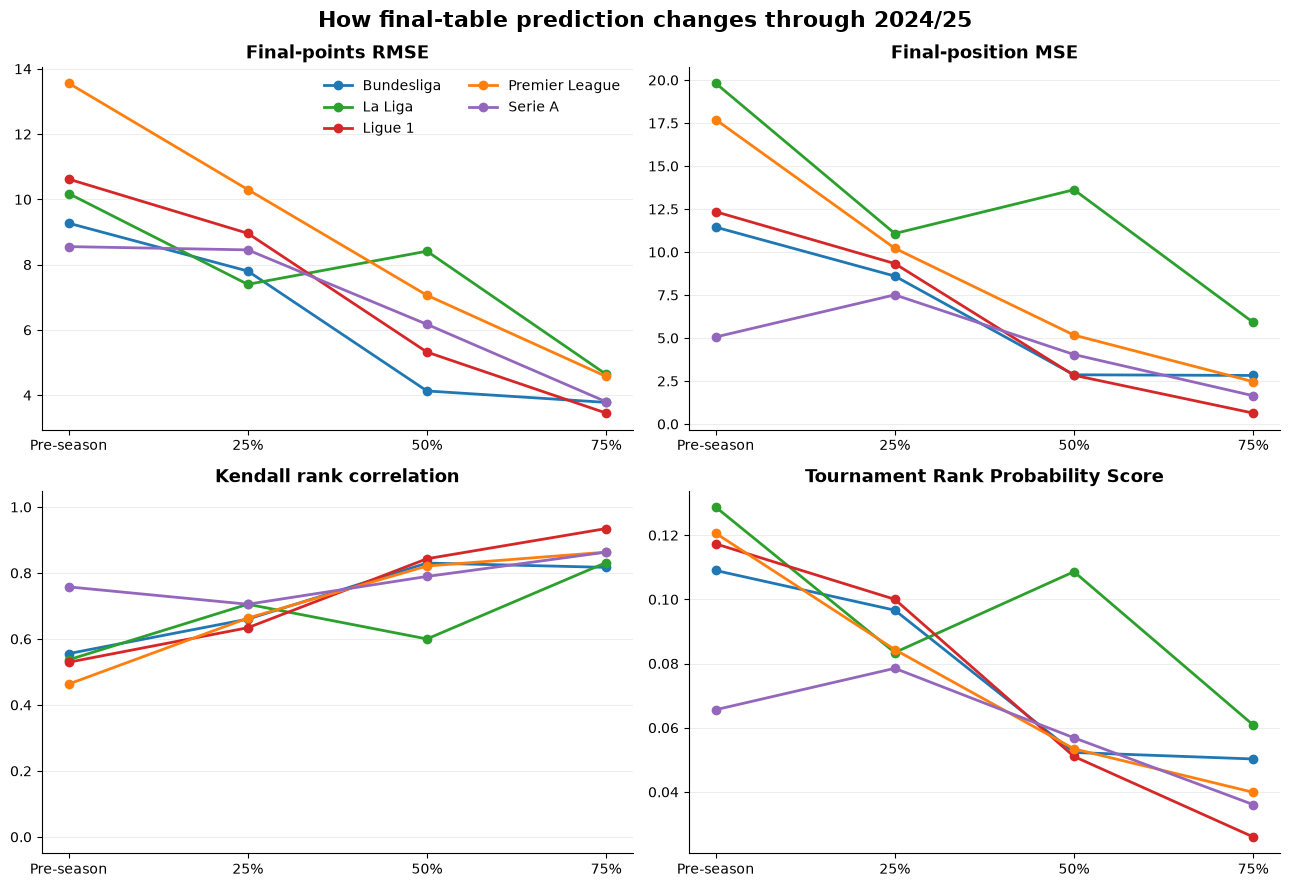

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metric_panels = [
    ("points_rmse", "Final-points RMSE", False),
    ("position_mse", "Final-position MSE", False),
    ("rank_kendall", "Kendall rank correlation", True),
    ("trps", "Tournament Rank Probability Score", False),
]
for axis, (metric, title, higher_better) in zip(axes.ravel(), metric_panels):
    for league_name, rows in simulation_evaluation.groupby("league"):
        rows = rows.sort_values("snapshot_order")
        axis.plot(
            rows["snapshot_order"], rows[metric], marker="o", linewidth=2,
            color=COLOURS[league_name], label=league_name,
        )
    axis.set_title(title)
    axis.set_xticks(range(4), ["Pre-season", "25%", "50%", "75%"])
    axis.grid(axis="y")
    if higher_better:
        axis.set_ylim(-0.05, 1.05)
axes[0, 0].legend(ncol=2, frameon=False)
fig.suptitle(
    "How final-table prediction changes through 2024/25",
    fontsize=16,
    fontweight="bold",
)
fig.tight_layout()
plt.show()


Lower RMSE, MSE, and TRPS indicate improvement. A Kendall value nearer one
means that more team pairs are ordered consistently with the realised table.
The four measures need not improve monotonically because each refit reacts to
a finite sequence of newly observed scores.


## 11. Expected points versus realised points

Every point represents one club. The diagonal is perfect agreement. Moving from pre-season to 75% should bring the cloud closer to the diagonal because a larger share of the final points total is already observed rather than simulated.

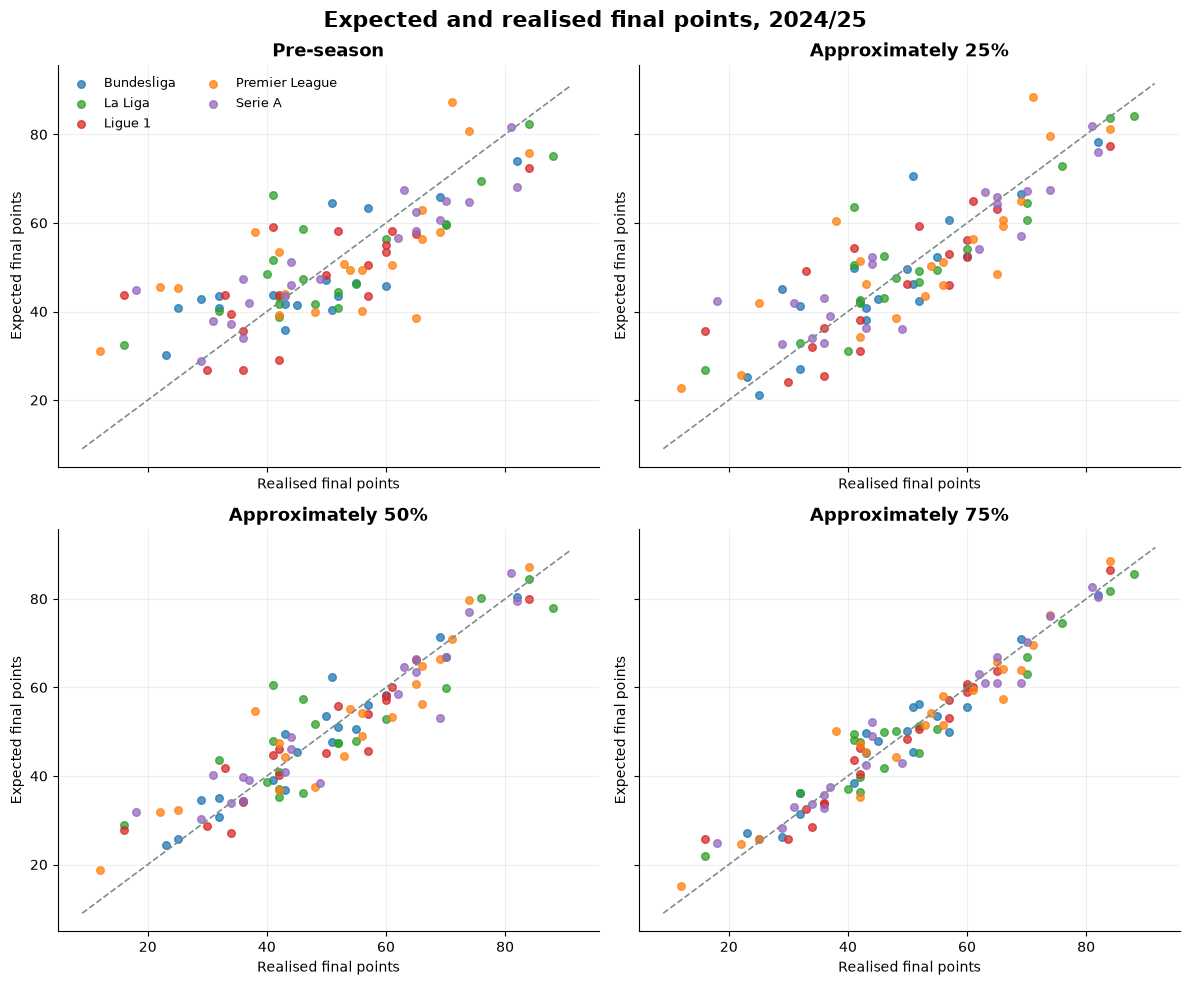

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for axis, (snapshot_code, snapshot_label, _) in zip(axes.ravel(), SNAPSHOTS):
    rows = simulation_results.loc[simulation_results["snapshot_code"].eq(snapshot_code)]
    for league_name, league_rows in rows.groupby("league"):
        axis.scatter(
            league_rows["actual_points"], league_rows["expected_points"],
            s=30, alpha=0.75, color=COLOURS[league_name], label=league_name,
        )
    lower = min(rows["actual_points"].min(), rows["expected_points"].min()) - 3
    upper = max(rows["actual_points"].max(), rows["expected_points"].max()) + 3
    axis.plot([lower, upper], [lower, upper], linestyle="--", color="#7F8C8D", linewidth=1.2)
    axis.set_title(snapshot_label)
    axis.set_xlabel("Realised final points")
    axis.set_ylabel("Expected final points")
    axis.grid(alpha=0.2)
axes[0, 0].legend(ncol=2, frameon=False, fontsize=9)
fig.suptitle("Expected and realised final points, 2024/25", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()

The scatter plots reveal both variance and shrinkage. Before the season, promoted teams assigned average strength can be visibly misplaced. Later snapshots inherit more realised points, so remaining model error is concentrated in the smaller unplayed part of the schedule.

## 12. Detailed league tables at every snapshot

Each table is sorted by expected final position and contains:

- current played matches, current points, and current rank at the snapshot;
- expected final points and position;
- 10th–90th percentile intervals;
- title, Champions League, broader European-position, direct-relegation, and play-off probabilities;
- the realised final points and official final rank.

The pre-season current-rank column is blank because every team has zero matches and an alphabetical ordering would have no sporting meaning.

In [12]:
def snapshot_presentation(rows):
    # Create a readable thesis table without modifying the numerical result table.
    table = rows.copy().sort_values(["expected_position", "expected_points"])
    table["points_80_interval"] = table.apply(
        lambda row: f"{row.points_p10:.0f}–{row.points_p90:.0f}", axis=1
    )
    table["position_80_interval"] = table.apply(
        lambda row: f"{row.position_p10:.0f}–{row.position_p90:.0f}", axis=1
    )
    table["observed_position"] = table["observed_position"].map(
        lambda value: "—" if pd.isna(value) else f"{int(value)}"
    )
    return table[[
        "team", "observed_team_matches", "observed_points", "observed_position",
        "expected_points", "points_80_interval", "expected_position", "position_80_interval",
        "title_probability", "champions_league_probability", "europe_probability",
        "direct_relegation_probability", "playoff_probability", "actual_points", "actual_position",
    ]].rename(columns={
        "team": "Team",
        "observed_team_matches": "Played",
        "observed_points": "Current pts",
        "observed_position": "Current rank",
        "expected_points": "Expected final pts",
        "points_80_interval": "Final pts 80% interval",
        "expected_position": "Expected rank",
        "position_80_interval": "Rank 80% interval",
        "title_probability": "Title",
        "champions_league_probability": "Champions League",
        "europe_probability": "European position",
        "direct_relegation_probability": "Direct relegation",
        "playoff_probability": "Play-off",
        "actual_points": "Final pts",
        "actual_position": "Final rank",
    })


def display_league_snapshots(league_id):
    league_name = LEAGUES[league_id]
    league_rows = simulation_results.loc[simulation_results["league_id"].eq(league_id)]
    display(Markdown(f"## {league_name}: simulated 2024/25 final tables"))
    for snapshot_code, snapshot_label, _ in SNAPSHOTS:
        rows = league_rows.loc[league_rows["snapshot_code"].eq(snapshot_code)].copy()
        completed = int(rows["completed_matches"].iloc[0])
        total = completed + int(rows["remaining_matches"].iloc[0])
        fraction = rows["completed_fraction"].iloc[0]
        display(Markdown(
            f"### {league_name} — {snapshot_label}: {completed}/{total} fixtures completed ({fraction:.1%})"
        ))
        table = snapshot_presentation(rows)
        display(table.style.hide(axis="index").format({
            "Expected final pts": "{:.1f}",
            "Expected rank": "{:.2f}",
            "Title": "{:.1%}",
            "Champions League": "{:.1%}",
            "European position": "{:.1%}",
            "Direct relegation": "{:.1%}",
            "Play-off": "{:.1%}",
        }).background_gradient(subset=["Title"], cmap="YlGn", vmin=0, vmax=1))
        expected_leader = rows.loc[rows["title_probability"].idxmax()]
        actual_champion = rows.loc[rows["actual_position"].eq(1)].iloc[0]
        mean_rank_width = np.mean(rows["position_p90"] - rows["position_p10"])
        display(Markdown(
            f"The highest title probability belongs to **{expected_leader.team}** "
            f"({expected_leader.title_probability:.1%}). The realised champion, "
            f"**{actual_champion.team}**, has probability **{actual_champion.title_probability:.1%}**. "
            f"The mean 80% rank interval is **{mean_rank_width:.1f} positions wide**."
        ))

The next output reports all four information snapshots for **Bundesliga**. Read probabilities within a snapshot; later rows use more observed results and a newly fitted score model.

In [13]:
display_league_snapshots("BUNDESLIGA")

## Bundesliga: simulated 2024/25 final tables

### Bundesliga — Pre-season: 0/306 fixtures completed (0.0%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Bayern Munich,0,0,—,74.0,65–83,1.53,1–3,65.2%,99.3%,99.9%,0.0%,0.0%,82,1
Bayer Leverkusen,0,0,—,65.8,57–75,2.86,1–4,14.6%,91.0%,98.3%,0.0%,0.0%,69,2
RasenBallsport Leipzig,0,0,—,64.4,55–74,3.15,1–5,10.9%,87.2%,97.0%,0.0%,0.0%,51,7
Borussia Dortmund,0,0,—,63.4,54–73,3.35,2–5,9.0%,84.1%,95.9%,0.0%,0.0%,57,4
VfB Stuttgart,0,0,—,47.1,38–57,8.80,5–14,0.1%,7.4%,32.9%,2.6%,2.7%,50,9
Freiburg,0,0,—,46.5,37–56,9.11,5–15,0.1%,6.5%,29.4%,3.1%,3.2%,55,5
Eintracht Frankfurt,0,0,—,45.9,36–55,9.42,5–15,0.0%,5.6%,26.6%,3.7%,3.8%,60,3
Union Berlin,0,0,—,43.7,34–53,10.48,6–16,0.0%,3.2%,17.8%,6.6%,5.4%,41,13
Hoffenheim,0,0,—,43.5,34–53,10.62,6–16,0.0%,3.0%,17.2%,6.8%,5.7%,32,15
Mainz 05,0,0,—,43.4,34–53,10.62,6–16,0.0%,2.9%,17.1%,6.9%,5.7%,52,6


The highest title probability belongs to **Bayern Munich** (65.2%). The realised champion, **Bayern Munich**, has probability **65.2%**. The mean 80% rank interval is **8.2 positions wide**.

### Bundesliga — Approximately 25%: 72/306 fixtures completed (23.5%)

...

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Bayern Munich,17,42,1,80.5,74–86,1.09,1–1,91.0%,100.0%,100.0%,0.0%,0.0%,82,1
Bayer Leverkusen,17,38,2,71.3,65–78,2.10,2–3,8.7%,99.2%,100.0%,0.0%,0.0%,69,2
RasenBallsport Leipzig,17,30,4,62.3,56–69,3.75,2–6,0.2%,78.6%,94.9%,0.0%,0.0%,51,7
Eintracht Frankfurt,17,33,3,58.3,52–65,4.85,3–7,0.0%,50.7%,83.0%,0.0%,0.0%,60,3
Borussia Dortmund,17,25,10,56.1,49–62,5.57,3–8,0.0%,33.2%,72.1%,0.0%,0.0%,57,4
VfB Stuttgart,17,29,5,53.5,47–60,6.71,4–10,0.0%,15.6%,49.5%,0.0%,0.0%,50,9
Mainz 05,17,28,6,51.1,45–58,7.63,5–11,0.0%,8.0%,31.9%,0.0%,0.0%,52,6
Freiburg,17,27,8,50.7,44–58,8.00,5–11,0.0%,6.7%,27.3%,0.0%,0.0%,55,5
Wolfsburg,17,27,7,49.4,43–56,8.31,5–11,0.0%,4.9%,22.1%,0.0%,0.1%,43,11
Werder Bremen,17,26,9,47.7,41–54,9.19,6–12,0.0%,2.2%,12.2%,0.0%,0.1%,51,8


The highest title probability belongs to **Bayern Munich** (91.0%). The realised champion, **Bayern Munich**, has probability **91.0%**. The mean 80% rank interval is **4.3 positions wide**.

### Bundesliga — Approximately 75%: 225/306 fixtures completed (73.5%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Bayern Munich,25,61,1,80.9,76–85,1.02,1–1,98.0%,100.0%,100.0%,0.0%,0.0%,82,1
Bayer Leverkusen,25,53,2,71.0,66–76,1.99,2–2,2.0%,100.0%,100.0%,0.0%,0.0%,69,2
Mainz 05,25,44,3,56.3,52–61,4.64,3–7,0.0%,56.0%,85.6%,0.0%,0.0%,52,6
Eintracht Frankfurt,25,42,4,55.6,51–61,4.98,3–8,0.0%,48.1%,80.1%,0.0%,0.0%,60,3
RasenBallsport Leipzig,25,39,6,55.6,51–61,5.02,3–8,0.0%,48.2%,79.7%,0.0%,0.0%,51,7
Freiburg,25,41,5,53.5,48–59,6.28,3–9,0.0%,23.5%,57.2%,0.0%,0.0%,55,5
VfB Stuttgart,25,37,8,50.2,45–55,7.85,5–11,0.0%,7.3%,27.7%,0.0%,0.0%,50,9
Borussia Dortmund,25,35,10,49.8,45–54,7.89,5–11,0.0%,7.0%,27.1%,0.0%,0.0%,57,4
Wolfsburg,25,38,7,49.8,45–55,8.01,5–11,0.0%,7.3%,26.3%,0.0%,0.0%,43,11
Borussia M.Gladbach,25,37,9,47.8,43–53,9.31,6–12,0.0%,1.9%,10.7%,0.0%,0.0%,45,10


The highest title probability belongs to **Bayern Munich** (98.0%). The realised champion, **Bayern Munich**, has probability **98.0%**. The mean 80% rank interval is **3.8 positions wide**.

The next output reports all four information snapshots for **Premier League**. Read probabilities within a snapshot; later rows use more observed results and a newly fitted score model.

In [14]:
display_league_snapshots("EPL")

## Premier League: simulated 2024/25 final tables

### Premier League — Pre-season: 0/380 fixtures completed (0.0%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Manchester City,0,0,—,87.4,79–96,1.39,1–2,69.5%,100.0%,100.0%,0.0%,0.0%,71,3
Arsenal,0,0,—,80.7,71–90,2.19,1–3,21.9%,99.5%,99.9%,0.0%,0.0%,74,2
Liverpool,0,0,—,75.7,66–85,2.89,2–4,8.2%,97.0%,99.3%,0.0%,0.0%,84,1
Newcastle United,0,0,—,62.8,53–73,5.69,3–9,0.3%,59.2%,81.1%,0.1%,0.0%,66,5
Chelsea,0,0,—,57.9,48–68,7.38,4–12,0.0%,33.5%,59.5%,0.4%,0.0%,69,4
Tottenham,0,0,—,58.0,48–68,7.38,4–12,0.0%,33.2%,59.6%,0.5%,0.0%,38,17
Aston Villa,0,0,—,56.4,46–67,8.00,4–13,0.0%,26.2%,51.3%,0.8%,0.0%,66,6
Manchester United,0,0,—,53.4,43–63,9.28,5–14,0.0%,14.8%,35.8%,2.0%,0.0%,42,15
Crystal Palace,0,0,—,50.7,41–61,10.56,6–16,0.0%,8.6%,23.8%,3.9%,0.0%,53,12
Brighton,0,0,—,50.5,41–60,10.65,6–16,0.0%,8.2%,22.7%,4.5%,0.0%,61,8


The highest title probability belongs to **Manchester City** (69.5%). The realised champion, **Liverpool**, has probability **8.2%**. The mean 80% rank interval is **7.5 positions wide**.

### Premier League — Approximately 25%: 90/380 fixtures completed (23.7%)

...

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Liverpool,18,45,1,87.1,80–94,1.19,1–2,82.4%,100.0%,100.0%,0.0%,0.0%,84,1
Arsenal,19,39,2,79.8,73–86,2.01,1–3,16.7%,99.9%,100.0%,0.0%,0.0%,74,2
Manchester City,19,31,6,71.0,64–78,3.54,2–5,0.7%,93.6%,99.1%,0.0%,0.0%,71,3
Chelsea,19,35,4,66.4,59–73,4.68,3–7,0.1%,76.1%,94.2%,0.0%,0.0%,69,4
Newcastle United,19,32,5,64.7,58–72,5.19,3–8,0.1%,65.2%,89.9%,0.0%,0.0%,66,5
Nottingham Forest,19,37,3,60.7,54–68,6.79,4–10,0.0%,29.5%,67.5%,0.0%,0.0%,65,7
Aston Villa,19,29,9,56.2,49–63,8.67,5–12,0.0%,10.1%,35.2%,0.0%,0.0%,66,6
Fulham,19,29,8,55.2,48–62,9.03,6–12,0.0%,7.7%,29.9%,0.0%,0.0%,54,11
Tottenham,19,24,11,54.6,48–62,9.07,6–13,0.0%,7.3%,29.5%,0.0%,0.0%,38,17
Bournemouth,19,30,7,54.3,47–61,9.41,6–13,0.0%,5.3%,24.3%,0.0%,0.0%,56,9


The highest title probability belongs to **Liverpool** (82.4%). The realised champion, **Liverpool**, has probability **82.4%**. The mean 80% rank interval is **4.7 positions wide**.

### Premier League — Approximately 75%: 281/380 fixtures completed (73.9%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Liverpool,29,70,1,88.6,84–93,1.01,1–1,98.8%,100.0%,100.0%,0.0%,0.0%,84,1
Arsenal,28,55,2,76.3,72–81,2.13,2–3,1.2%,99.9%,100.0%,0.0%,0.0%,74,2
Manchester City,28,47,5,69.5,65–74,3.48,3–5,0.0%,95.1%,99.5%,0.0%,0.0%,71,3
Nottingham Forest,28,51,3,65.8,61–71,4.91,3–7,0.0%,69.1%,93.9%,0.0%,0.0%,65,7
Chelsea,28,49,4,64.0,59–69,5.45,4–8,0.0%,54.9%,89.4%,0.0%,0.0%,69,4
Newcastle United,28,47,6,64.1,59–69,5.51,4–8,0.0%,54.4%,88.0%,0.0%,0.0%,66,5
Brighton,28,46,7,59.4,54–65,7.72,5–10,0.0%,12.1%,47.5%,0.0%,0.0%,61,8
Bournemouth,28,44,9,58.2,53–63,8.12,6–11,0.0%,8.2%,39.5%,0.0%,0.0%,56,9
Aston Villa,29,45,8,57.3,52–62,8.83,6–11,0.0%,4.5%,25.3%,0.0%,0.0%,66,6
Fulham,28,42,10,54.2,49–59,10.35,8–13,0.0%,1.0%,8.8%,0.0%,0.0%,54,11


The highest title probability belongs to **Liverpool** (98.8%). The realised champion, **Liverpool**, has probability **98.8%**. The mean 80% rank interval is **3.2 positions wide**.

The next output reports all four information snapshots for **La Liga**. Read probabilities within a snapshot; later rows use more observed results and a newly fitted score model.

In [15]:
display_league_snapshots("LALIGA")

## La Liga: simulated 2024/25 final tables

### La Liga — Pre-season: 0/380 fixtures completed (0.0%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Real Madrid,0,0,—,82.3,73–91,1.48,1–3,67.5%,99.7%,100.0%,0.0%,0.0%,84,2
Barcelona,0,0,—,75.2,66–85,2.54,1–4,21.3%,95.9%,99.6%,0.0%,0.0%,88,1
Atletico Madrid,0,0,—,69.4,60–79,3.79,2–6,6.6%,84.1%,97.4%,0.0%,0.0%,76,3
Girona,0,0,—,66.3,56–76,4.60,2–8,3.1%,72.1%,93.7%,0.0%,0.0%,41,16
Athletic Club,0,0,—,59.7,50–70,6.75,3–11,0.5%,37.2%,76.5%,0.2%,0.0%,70,4
Villarreal,0,0,—,59.5,50–69,6.83,4–11,0.4%,36.4%,75.6%,0.2%,0.0%,70,5
Real Sociedad,0,0,—,58.7,49–69,7.14,4–11,0.3%,31.7%,72.2%,0.3%,0.0%,46,11
Real Betis,0,0,—,56.4,47–66,8.04,4–12,0.2%,21.8%,61.0%,0.6%,0.0%,60,6
Sevilla,0,0,—,51.6,42–61,10.10,6–15,0.0%,8.5%,35.5%,3.1%,0.0%,41,17
Leganes,0,0,—,48.5,39–58,11.57,7–17,0.0%,3.9%,21.9%,6.5%,0.0%,40,18


The highest title probability belongs to **Real Madrid** (67.5%). The realised champion, **Barcelona**, has probability **21.3%**. The mean 80% rank interval is **7.5 positions wide**.

### La Liga — Approximately 25%: 90/380 fixtures completed (23.7%)

...

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Real Madrid,19,43,2,84.4,78–91,1.48,1–3,63.3%,100.0%,100.0%,0.0%,0.0%,84,2
Atletico Madrid,19,44,1,80.1,73–87,2.20,1–3,22.3%,99.9%,100.0%,0.0%,0.0%,76,3
Barcelona,19,38,3,77.9,71–84,2.47,1–3,14.2%,99.8%,100.0%,0.0%,0.0%,88,1
Athletic Club,19,36,4,66.9,60–74,4.47,4–6,0.2%,85.5%,99.3%,0.0%,0.0%,70,4
Girona,19,28,8,60.6,54–67,6.06,4–8,0.0%,43.6%,91.7%,0.0%,0.0%,41,16
Villarreal,19,30,5,59.9,53–67,6.30,4–9,0.0%,37.9%,88.8%,0.0%,0.0%,70,5
Real Sociedad,19,28,7,57.4,51–64,7.09,5–10,0.0%,21.4%,79.2%,0.0%,0.0%,46,11
Real Betis,19,25,10,52.9,46–60,8.97,6–12,0.0%,5.6%,47.2%,0.1%,0.0%,60,6
Mallorca,19,30,6,51.8,45–58,9.65,7–13,0.0%,3.0%,34.3%,0.1%,0.0%,48,10
Celta Vigo,19,24,12,47.9,41–55,11.38,8–15,0.0%,0.8%,15.5%,1.4%,0.0%,55,7


The highest title probability belongs to **Real Madrid** (63.3%). The realised champion, **Barcelona**, has probability **14.2%**. The mean 80% rank interval is **5.0 positions wide**.

### La Liga — Approximately 75%: 289/380 fixtures completed (76.1%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Barcelona,29,66,1,85.6,81–90,1.21,1–2,79.8%,100.0%,100.0%,0.0%,0.0%,88,1
Real Madrid,29,63,2,81.7,77–86,1.88,1–2,19.9%,100.0%,100.0%,0.0%,0.0%,84,2
Atletico Madrid,29,57,3,74.6,70–79,3.01,3–3,0.3%,100.0%,100.0%,0.0%,0.0%,76,3
Athletic Club,29,53,4,67.0,62–72,4.23,4–5,0.0%,95.7%,100.0%,0.0%,0.0%,70,4
Villarreal,28,47,5,62.9,58–68,5.10,4–6,0.0%,71.9%,99.7%,0.0%,0.0%,70,5
Real Betis,29,47,6,60.1,55–65,5.83,5–7,0.0%,30.9%,98.7%,0.0%,0.0%,60,6
Rayo Vallecano,29,40,7,51.3,47–56,9.18,7–12,0.0%,0.5%,45.1%,0.0%,0.0%,52,8
Celta Vigo,29,40,8,50.5,46–55,9.72,7–13,0.0%,0.3%,36.0%,0.0%,0.0%,55,7
Real Sociedad,29,38,10,49.9,45–55,10.15,7–13,0.0%,0.3%,29.1%,0.0%,0.0%,46,11
Mallorca,29,40,9,50.1,46–54,10.22,7–13,0.0%,0.1%,26.9%,0.0%,0.0%,48,10


The highest title probability belongs to **Barcelona** (79.8%). The realised champion, **Barcelona**, has probability **79.8%**. The mean 80% rank interval is **3.8 positions wide**.

The next output reports all four information snapshots for **Ligue 1**. Read probabilities within a snapshot; later rows use more observed results and a newly fitted score model.

In [16]:
display_league_snapshots("LIGUE_1")

## Ligue 1: simulated 2024/25 final tables

### Ligue 1 — Pre-season: 0/306 fixtures completed (0.0%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Paris Saint Germain,0,0,—,72.4,64–81,1.44,1–3,75.1%,97.8%,99.8%,0.0%,0.0%,84,1
Rennes,0,0,—,59.1,50–69,4.60,2–8,6.3%,56.3%,85.4%,0.0%,0.0%,41,12
Monaco,0,0,—,58.2,49–68,4.89,2–9,5.1%,51.7%,82.7%,0.0%,0.0%,61,3
Lens,0,0,—,58.2,49–68,4.93,2–9,4.6%,50.9%,82.2%,0.0%,0.0%,52,8
Marseille,0,0,—,57.4,48–67,5.20,2–9,4.3%,46.8%,79.7%,0.0%,0.0%,65,2
Lille,0,0,—,55.1,46–65,6.12,2–10,2.2%,34.2%,69.3%,0.0%,0.1%,60,5
Nice,0,0,—,53.4,44–63,6.79,3–11,1.2%,25.6%,61.5%,0.1%,0.1%,60,4
Lyon,0,0,—,50.5,41–60,8.01,4–12,0.7%,15.6%,44.6%,0.2%,0.5%,57,6
Brest,0,0,—,48.2,39–58,9.02,5–13,0.3%,9.0%,31.8%,0.4%,1.0%,50,9
Reims,0,0,—,43.8,35–53,10.93,7–15,0.0%,2.7%,14.0%,1.7%,3.3%,33,16


The highest title probability belongs to **Paris Saint Germain** (75.1%). The realised champion, **Paris Saint Germain**, has probability **75.1%**. The mean 80% rank interval is **6.4 positions wide**.

### Ligue 1 — Approximately 25%: 72/306 fixtures completed (23.5%)

...

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Paris Saint Germain,17,43,1,80.0,74–86,1.03,1–1,97.0%,100.0%,100.0%,0.0%,0.0%,84,1
Marseille,17,36,2,66.3,60–73,2.56,2–4,2.7%,93.4%,99.8%,0.0%,0.0%,65,2
Monaco,17,31,3,60.1,53–67,4.15,2–6,0.2%,63.8%,96.3%,0.0%,0.0%,61,3
Nice,17,30,4,58.0,51–65,4.79,3–7,0.1%,48.0%,92.8%,0.0%,0.0%,60,4
Lille,17,29,5,57.3,51–64,5.06,3–7,0.0%,41.8%,90.8%,0.0%,0.0%,60,5
Lens,17,27,7,55.8,49–62,5.66,3–8,0.0%,29.3%,84.4%,0.0%,0.0%,52,8
Lyon,17,28,6,54.0,47–61,6.30,4–9,0.0%,19.9%,74.4%,0.0%,0.0%,57,6
Toulouse,17,24,8,46.0,39–53,9.66,7–13,0.0%,1.1%,15.9%,0.1%,0.2%,42,10
Strasbourg,17,23,9,45.5,39–52,9.80,7–13,0.0%,0.9%,14.4%,0.1%,0.3%,57,7
Rennes,17,17,14,44.8,38–52,9.96,7–13,0.0%,0.7%,13.0%,0.2%,0.4%,41,12


The highest title probability belongs to **Paris Saint Germain** (97.0%). The realised champion, **Paris Saint Germain**, has probability **97.0%**. The mean 80% rank interval is **4.4 positions wide**.

### Ligue 1 — Approximately 75%: 225/306 fixtures completed (73.5%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Paris Saint Germain,25,65,1,86.4,82–90,1.00,1–1,100.0%,100.0%,100.0%,0.0%,0.0%,84,1
Marseille,25,49,2,63.6,59–68,2.92,2–5,0.0%,88.2%,99.9%,0.0%,0.0%,65,2
Nice,25,46,3,60.8,56–65,3.89,2–6,0.0%,67.9%,99.0%,0.0%,0.0%,60,4
Monaco,25,44,4,60.0,55–65,4.13,2–6,0.0%,60.9%,97.6%,0.0%,0.0%,61,3
Lille,25,44,5,59.0,54–64,4.69,3–7,0.0%,45.4%,96.3%,0.0%,0.0%,60,5
Lyon,25,42,6,57.2,52–62,5.31,3–7,0.0%,30.9%,91.8%,0.0%,0.0%,57,6
Strasbourg,25,40,7,53.0,48–58,7.16,5–9,0.0%,4.9%,60.4%,0.0%,0.0%,57,7
Lens,25,36,8,50.7,46–56,8.15,6–10,0.0%,1.5%,32.2%,0.0%,0.0%,52,8
Brest,25,36,9,48.4,44–53,9.06,7–11,0.0%,0.3%,13.4%,0.0%,0.0%,50,9
Toulouse,25,34,10,46.2,41–51,9.67,8–11,0.0%,0.1%,7.6%,0.0%,0.0%,42,10


The highest title probability belongs to **Paris Saint Germain** (100.0%). The realised champion, **Paris Saint Germain**, has probability **100.0%**. The mean 80% rank interval is **3.2 positions wide**.

The next output reports all four information snapshots for **Serie A**. Read probabilities within a snapshot; later rows use more observed results and a newly fitted score model.

In [17]:
display_league_snapshots("SERIE_A")

## Serie A: simulated 2024/25 final tables

### Serie A — Pre-season: 0/380 fixtures completed (0.0%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Inter,0,0,—,81.7,72–91,1.39,1–2,76.9%,98.2%,99.7%,0.0%,0.0%,81,2
Napoli,0,0,—,68.2,58–78,4.19,2–8,6.7%,62.7%,83.4%,0.0%,0.0%,82,1
AC Milan,0,0,—,67.4,58–77,4.43,2–8,6.1%,58.9%,80.5%,0.0%,0.0%,63,8
Juventus,0,0,—,65.1,55–75,5.20,2–9,3.3%,45.6%,71.1%,0.0%,0.0%,70,4
Atalanta,0,0,—,64.7,55–75,5.30,2–9,3.4%,44.2%,69.6%,0.0%,0.0%,74,3
Lazio,0,0,—,62.5,53–73,6.10,2–10,1.7%,32.7%,58.7%,0.0%,0.0%,65,7
Roma,0,0,—,60.7,51–71,6.77,3–11,1.1%,24.6%,49.1%,0.1%,0.0%,69,5
Fiorentina,0,0,—,58.2,48–68,7.81,4–12,0.5%,15.7%,35.4%,0.2%,0.0%,65,6
Bologna,0,0,—,56.6,47–67,8.45,4–13,0.3%,11.2%,27.8%,0.4%,0.0%,62,9
Torino,0,0,—,51.1,41–61,10.77,7–15,0.0%,2.8%,9.8%,2.2%,0.0%,44,11


The highest title probability belongs to **Inter** (76.9%). The realised champion, **Napoli**, has probability **6.7%**. The mean 80% rank interval is **7.0 positions wide**.

### Serie A — Approximately 25%: 99/380 fixtures completed (26.1%)

...

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Inter,17,40,3,85.9,79–92,1.32,1–2,74.8%,99.9%,100.0%,0.0%,0.0%,81,2
Napoli,19,44,1,79.6,73–86,2.38,1–3,16.2%,97.0%,99.8%,0.0%,0.0%,82,1
Atalanta,18,41,2,77.1,70–84,2.80,2–4,8.7%,93.2%,99.3%,0.0%,0.0%,74,3
Juventus,18,32,5,66.9,60–74,5.18,3–7,0.2%,37.2%,79.5%,0.0%,0.0%,70,4
Lazio,19,35,4,66.4,59–73,5.46,4–8,0.1%,30.3%,73.9%,0.0%,0.0%,65,7
AC Milan,17,27,8,64.7,57–72,5.83,4–8,0.1%,22.8%,65.5%,0.0%,0.0%,63,8
Fiorentina,18,32,6,63.4,56–71,6.23,4–8,0.0%,15.6%,55.2%,0.0%,0.0%,65,6
Bologna,17,28,7,58.6,51–66,7.66,5–9,0.0%,3.7%,21.6%,0.0%,0.0%,62,9
Roma,19,23,10,53.1,46–60,9.12,7–11,0.0%,0.3%,4.3%,0.0%,0.0%,69,5
Udinese,19,25,9,48.7,42–56,10.66,9–13,0.0%,0.0%,0.7%,0.3%,0.0%,44,12


The highest title probability belongs to **Inter** (74.8%). The realised champion, **Napoli**, has probability **16.2%**. The mean 80% rank interval is **4.6 positions wide**.

### Serie A — Approximately 75%: 280/380 fixtures completed (73.7%)

Team,Played,Current pts,Current rank,Expected final pts,Final pts 80% interval,Expected rank,Rank 80% interval,Title,Champions League,European position,Direct relegation,Play-off,Final pts,Final rank
Inter,28,61,1,82.6,78–87,1.45,1–2,65.0%,100.0%,100.0%,0.0%,0.0%,81,2
Napoli,28,60,2,80.4,75–85,1.98,1–3,27.7%,99.7%,100.0%,0.0%,0.0%,82,1
Atalanta,28,58,3,76.0,71–81,2.84,2–4,7.2%,96.8%,99.9%,0.0%,0.0%,74,3
Juventus,28,52,4,70.3,65–75,4.33,3–6,0.1%,68.1%,95.6%,0.0%,0.0%,70,4
Lazio,28,51,5,66.8,62–72,5.43,4–7,0.0%,23.1%,80.4%,0.0%,0.0%,65,7
Bologna,28,50,6,63.0,58–68,6.90,5–9,0.0%,5.5%,41.0%,0.0%,0.0%,62,9
Fiorentina,28,45,8,61.0,56–66,7.42,5–9,0.0%,2.5%,28.5%,0.0%,0.0%,65,6
AC Milan,28,44,9,61.0,56–66,7.45,5–9,0.0%,2.0%,27.6%,0.0%,0.0%,63,8
Roma,28,46,7,60.9,56–66,7.46,5–9,0.0%,2.4%,26.8%,0.0%,0.0%,69,5
Udinese,28,40,10,52.1,47–57,10.24,9–11,0.0%,0.0%,0.3%,0.0%,0.0%,44,12


The highest title probability belongs to **Inter** (65.0%). The realised champion, **Napoli**, has probability **27.7%**. The mean 80% rank interval is **3.3 positions wide**.

## 13. Title and relegation-risk evolution

The complete tables contain all clubs, but event probabilities are easier to compare in focused heatmaps. The left panel retains the six clubs with the largest title probability at any snapshot, plus the realised champion. The right panel retains the six largest direct-relegation or play-off risks at any snapshot.

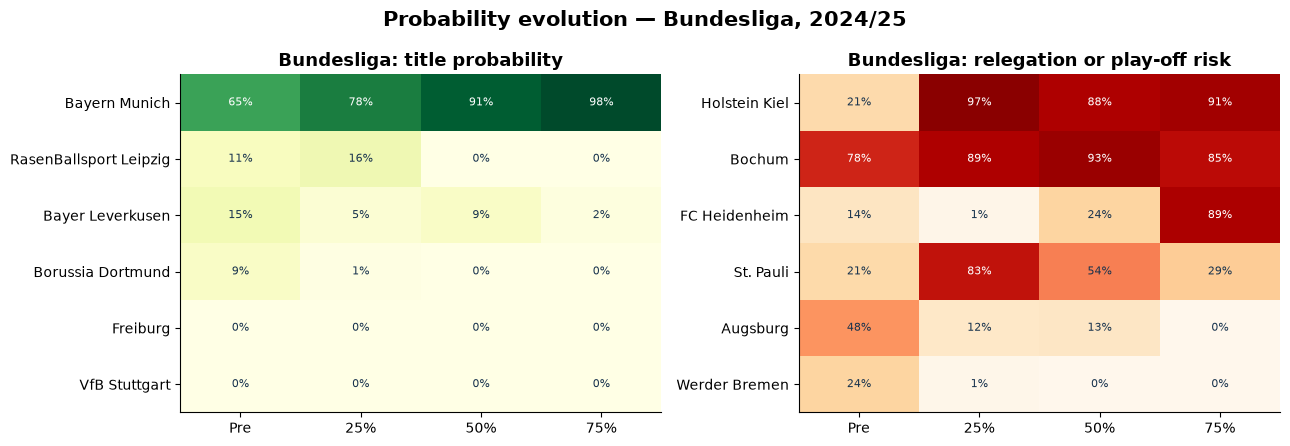

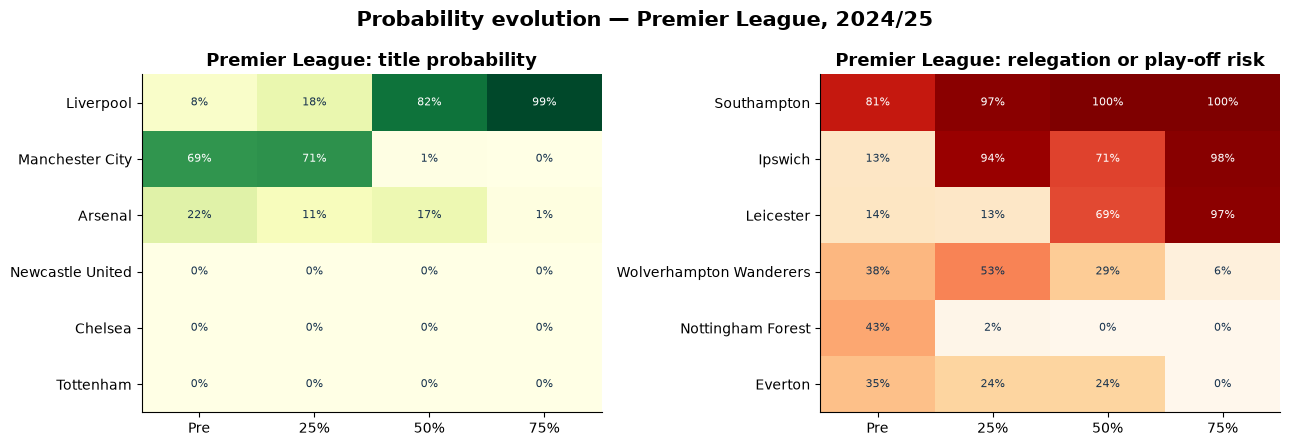

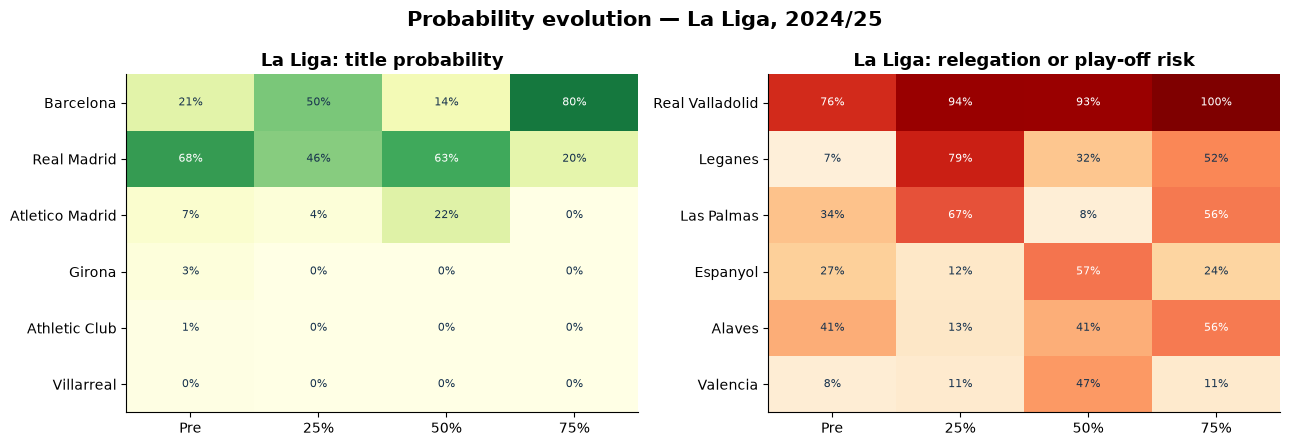

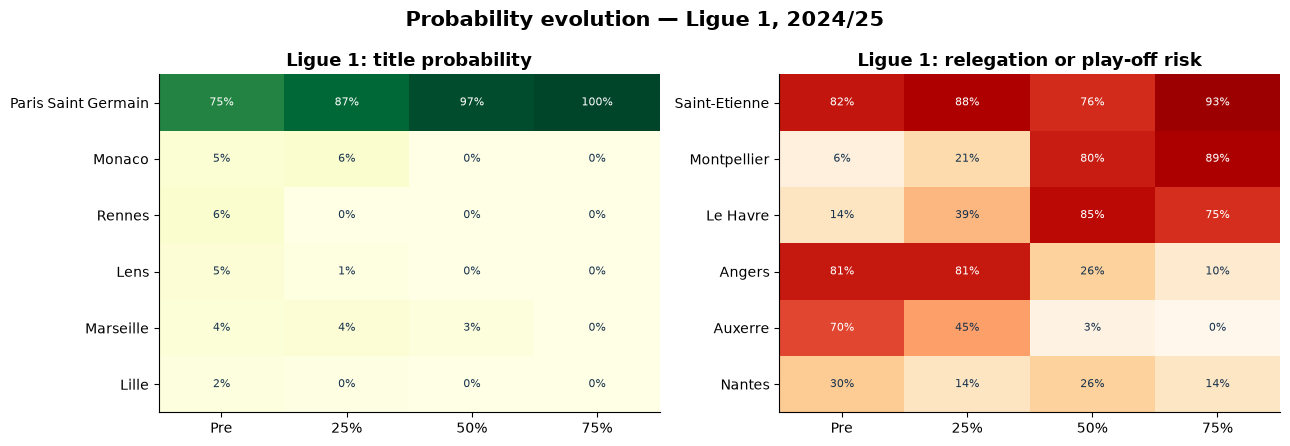

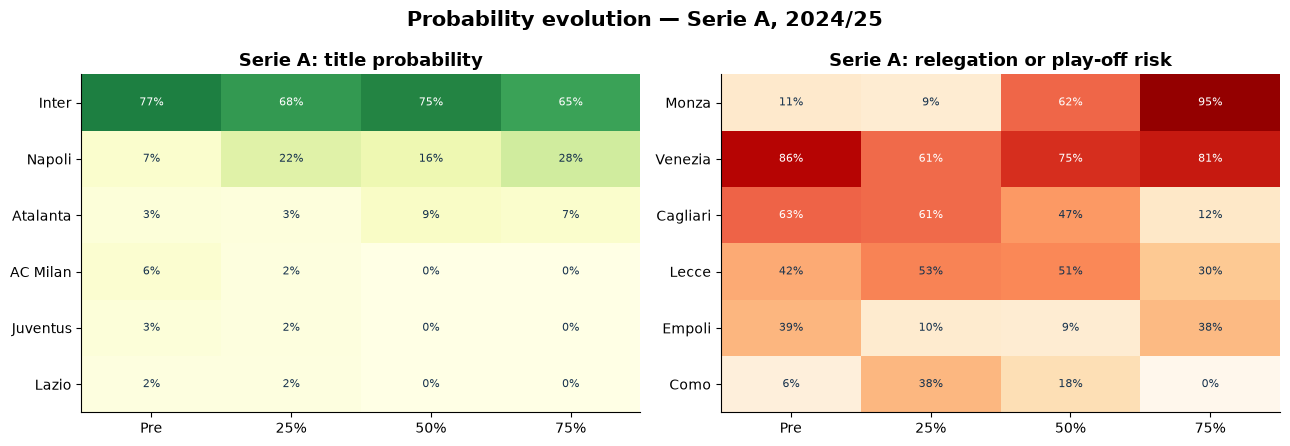

In [18]:
def probability_heatmap(axis, data, teams, value, title, cmap):
    matrix = data.pivot(index="team", columns="snapshot_order", values=value).reindex(teams)
    matrix = matrix.reindex(columns=range(4))
    image = axis.imshow(matrix.to_numpy(), aspect="auto", cmap=cmap, vmin=0, vmax=1)
    axis.set_xticks(range(4), ["Pre", "25%", "50%", "75%"])
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set_title(title)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value_at_cell = matrix.iloc[row, column]
            axis.text(
                column, row, f"{value_at_cell:.0%}", ha="center", va="center",
                color="white" if value_at_cell > 0.55 else "#17324D", fontsize=8,
            )
    return image


for league_id, league_name in LEAGUES.items():
    rows = simulation_results.loc[simulation_results["league_id"].eq(league_id)].copy()
    title_peak = rows.groupby("team")["title_probability"].max().sort_values(ascending=False)
    title_teams = list(title_peak.head(6).index)
    actual_champion = rows.loc[rows["actual_position"].eq(1), "team"].iloc[0]
    if actual_champion not in title_teams:
        title_teams.append(actual_champion)

    rows["relegation_or_playoff"] = (
        rows["direct_relegation_probability"] + rows["playoff_probability"]
    )
    risk_peak = rows.groupby("team")["relegation_or_playoff"].max().sort_values(ascending=False)
    risk_teams = list(risk_peak.head(6).index)

    fig, axes = plt.subplots(1, 2, figsize=(13, max(4.5, 0.55 * max(len(title_teams), len(risk_teams)))))
    probability_heatmap(
        axes[0], rows, title_teams, "title_probability",
        f"{league_name}: title probability", "YlGn",
    )
    probability_heatmap(
        axes[1], rows, risk_teams, "relegation_or_playoff",
        f"{league_name}: relegation or play-off risk", "OrRd",
    )
    fig.suptitle(f"Probability evolution — {league_name}, 2024/25", fontsize=15, fontweight="bold")
    fig.tight_layout()
    plt.show()

Dark cells indicate concentrated probability. The heatmaps also reveal whether uncertainty was resolved smoothly or abruptly. A probability can move away from the realised outcome because the model updates team strength from a finite and sometimes surprising sequence of scores.

## 14. What the simulation does and does not estimate

The calculation includes:

- uncertainty in every remaining match score;
- the actual remaining home–away schedule;
- snapshot-specific Poisson refitting;
- time decay selected during development;
- realised results fixed before the cutoff;
- league-specific position thresholds.

It does not include:

- uncertainty in $\widehat\mu$, $\widehat\mu_H$, $\widehat{att}$, or $\widehat{def}$;
- injuries, transfers, manager changes, line-ups, or future player ratings;
- future evolution of ML rolling features;
- dependence between home and away goals or common shocks across fixtures;
- domestic cup outcomes or European Performance Spot uncertainty;
- exact head-to-head tie-break rules inside every simulated table;
- the result of a relegation play-off after a club enters it.

The reported intervals are therefore **conditional predictive intervals**, not complete Bayesian credible intervals. They may be too narrow when parameter uncertainty or structural change is important.

## 15. Compact final comparison

The final comparison joins the four thesis evaluation measures with the most
likely and realised champion for every league and information snapshot.
It is the bridge from the detailed simulation output to the thesis results
chapter.


In [19]:
compact = simulation_evaluation[[
    "league", "snapshot", "completed_fraction", "predicted_champion",
    "actual_champion", "actual_champion_probability", "points_rmse",
    "position_mse", "rank_kendall", "trps",
    "correct_european_teams", "european_places",
    "correct_direct_relegation_teams", "direct_relegation_places",
]].copy()
display(compact.style.hide(axis="index").format({
    "completed_fraction": "{:.1%}",
    "actual_champion_probability": "{:.1%}",
    "points_rmse": "{:.2f}",
    "position_mse": "{:.2f}",
    "rank_kendall": "{:.3f}",
    "trps": "{:.4f}",
}))

preseason = simulation_evaluation.loc[
    simulation_evaluation["snapshot_order"].eq(0)
]
late = simulation_evaluation.loc[
    simulation_evaluation["snapshot_order"].eq(3)
]
display(Markdown(
    f"Before the season, the most likely champion is correct in "
    f"**{int(preseason.predicted_champion_correct.sum())} of 5 leagues**. "
    f"After approximately 75%, it is correct in "
    f"**{int(late.predicted_champion_correct.sum())} of 5**. "
    f"Mean final-position MSE changes from "
    f"**{preseason.position_mse.mean():.2f}** to "
    f"**{late.position_mse.mean():.2f}**."
))


league,snapshot,completed_fraction,predicted_champion,actual_champion,actual_champion_probability,points_rmse,position_mse,rank_kendall,trps,correct_european_teams,european_places,correct_direct_relegation_teams,direct_relegation_places
Bundesliga,Pre-season,0.0%,Bayern Munich,Bayern Munich,65.2%,9.27,11.45,0.556,0.1090,4,6,1,2
Bundesliga,Approximately 25%,23.5%,Bayern Munich,Bayern Munich,78.0%,7.80,8.60,0.660,0.0966,5,6,2,2
Bundesliga,Approximately 50%,50.0%,Bayern Munich,Bayern Munich,91.0%,4.13,2.86,0.830,0.0523,4,6,2,2
Bundesliga,Approximately 75%,73.5%,Bayern Munich,Bayern Munich,98.0%,3.78,2.82,0.817,0.0503,5,6,1,2
La Liga,Pre-season,0.0%,Real Madrid,Barcelona,21.3%,10.18,19.82,0.537,0.1288,6,8,2,3
La Liga,Approximately 25%,23.7%,Barcelona,Barcelona,49.6%,7.40,11.08,0.705,0.0834,6,8,3,3
La Liga,Approximately 50%,50.0%,Real Madrid,Barcelona,14.2%,8.41,13.62,0.600,0.1086,6,8,1,3
La Liga,Approximately 75%,76.1%,Barcelona,Barcelona,79.8%,4.64,5.91,0.832,0.0609,8,8,2,3
Ligue 1,Pre-season,0.0%,Paris Saint Germain,Paris Saint Germain,75.1%,10.62,12.35,0.529,0.1173,5,7,1,2
Ligue 1,Approximately 25%,23.5%,Paris Saint Germain,Paris Saint Germain,87.2%,8.96,9.33,0.634,0.1000,5,7,1,2


Before the season, the most likely champion is correct in **2 of 5 leagues**. After approximately 75%, it is correct in **4 of 5**. Mean final-position MSE changes from **13.28** to **2.70**.

## 16. Reproducible exports for thesis reporting

The next cell stores the team-level summaries, the full position
probability distributions, and the agreed evaluation measures in the same
ignored cache directory as Notebook 06. The Czech reporting notebook can
therefore recreate every thesis table and figure without rerunning the
Monte Carlo simulation.


In [20]:
REPORTING_DIR = PROJECT_ROOT / ".cache" / "thesis_cs"
REPORTING_DIR.mkdir(parents=True, exist_ok=True)

simulation_results.to_parquet(
    REPORTING_DIR / "season_simulation_results.parquet",
    index=False,
    compression="zstd",
)
position_probabilities.to_parquet(
    REPORTING_DIR / "season_position_probabilities.parquet",
    index=False,
    compression="zstd",
)
simulation_evaluation.to_csv(
    REPORTING_DIR / "season_evaluation.csv",
    index=False,
    encoding="utf-8",
)
snapshot_plan.to_csv(
    REPORTING_DIR / "season_snapshot_plan.csv",
    index=False,
    encoding="utf-8",
)
fit_audit.to_csv(
    REPORTING_DIR / "season_fit_audit.csv",
    index=False,
    encoding="utf-8",
)

print(f"Thesis-reporting artifacts exported to: {REPORTING_DIR}")


Thesis-reporting artifacts exported to: C:\Users\cerve\Desktop\DP\match_prediction\.cache\thesis_cs


## 17. Conclusion

The four-snapshot experiment shows how a long-range probabilistic forecast
changes as completed matches replace simulated ones. The pre-season estimate
is a structural forecast based only on 2021/22-2023/24 top-flight goals. The
later estimates combine fixed observed points with newly estimated team
strengths and simulated remaining scores.

Evaluation is not reduced to whether the most likely champion was correct.
Final-points RMSE, final-position MSE, Kendall's tau, and TRPS describe
complementary aspects of forecast quality. The retained 10th-90th percentile
intervals and event probabilities provide the uncertainty needed for
substantive interpretation.

Together with Notebook 06, this notebook separates match-level classification
under a pseudo-live walk-forward design from long-range uncertainty over a
complete league table.
